<a href="https://colab.research.google.com/github/aggelikntaliani-lgtm/end_to_end_drug_discovery_project_-python-/blob/main/Comparing%20Regressors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Comparing Regressors

In [1]:
! pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 2.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import lazypredict
from lazypredict.Supervised import LazyRegressor

In [4]:
df = pd.read_csv('acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv')

In [5]:
X = df.drop('pIC50', axis=1)
Y = df.pIC50

Data pre-processing

In [6]:
# Examine X dimension
X.shape

(4695, 881)

In [7]:
# Remove low variance features
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
X = selection.fit_transform(X)
X.shape

(4695, 137)

In [8]:
# Perform data splitting using 80/20 ratio
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

Compare ML algorithms

In [11]:
# Defines and builds the lazyclassifier
clf = LazyRegressor(verbose=0,ignore_warnings=True, custom_metric=None)
models_train, predictions_train = clf.fit(X_train, X_train, Y_train, Y_train)
models_test, predictions_test = clf.fit(X_train, X_test, Y_train, Y_test)


In [13]:
#80% subset
models_train

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
ExtraTreeRegressor,0.859408,0.864538,0.571388,0.188142
DecisionTreeRegressor,0.859408,0.864538,0.571388,0.164752
ExtraTreesRegressor,0.859408,0.864538,0.571388,8.358180
GaussianProcessRegressor,0.859408,0.864538,0.571388,6.910273
RandomForestRegressor,0.822878,0.829340,0.641338,6.685548
XGBRegressor,0.819598,0.826180,0.647249,0.426308
BaggingRegressor,0.804288,0.811428,0.674155,0.616053
MLPRegressor,0.757521,0.766367,0.750392,9.923761
HistGradientBoostingRegressor,0.674207,0.686094,0.869805,1.291900


In [15]:
#20% subset
models_test

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
HistGradientBoostingRegressor,0.455519,0.535044,1.059035,1.344990
RandomForestRegressor,0.438623,0.520616,1.075341,5.619228
LGBMRegressor,0.437692,0.519820,1.076233,0.539036
XGBRegressor,0.436528,0.518826,1.077346,1.165043
BaggingRegressor,0.405035,0.491933,1.107044,0.853711
NuSVR,0.389303,0.478499,1.121584,2.288710
SVR,0.389268,0.478469,1.121616,2.382541
KNeighborsRegressor,0.371334,0.463154,1.137965,0.146776
MLPRegressor,0.358628,0.452304,1.149408,6.920403


Data visualization of model performance

[(0.0, 1.0)]

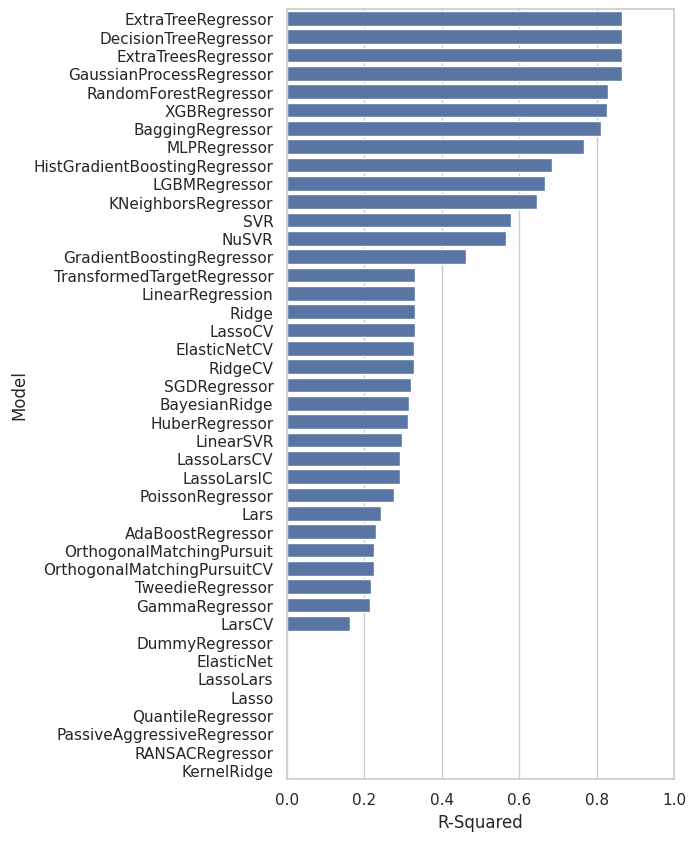

In [17]:
# Bar plot of R-squared values
import matplotlib.pyplot as plt
import seaborn as sns

#train["R-Squared"] = [0 if i < 0 else i for i in train.iloc[:,0] ]

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=models_train.index, x="R-Squared", data=models_train)
ax.set(xlim=(0, 1))

[(0.0, 10.0)]

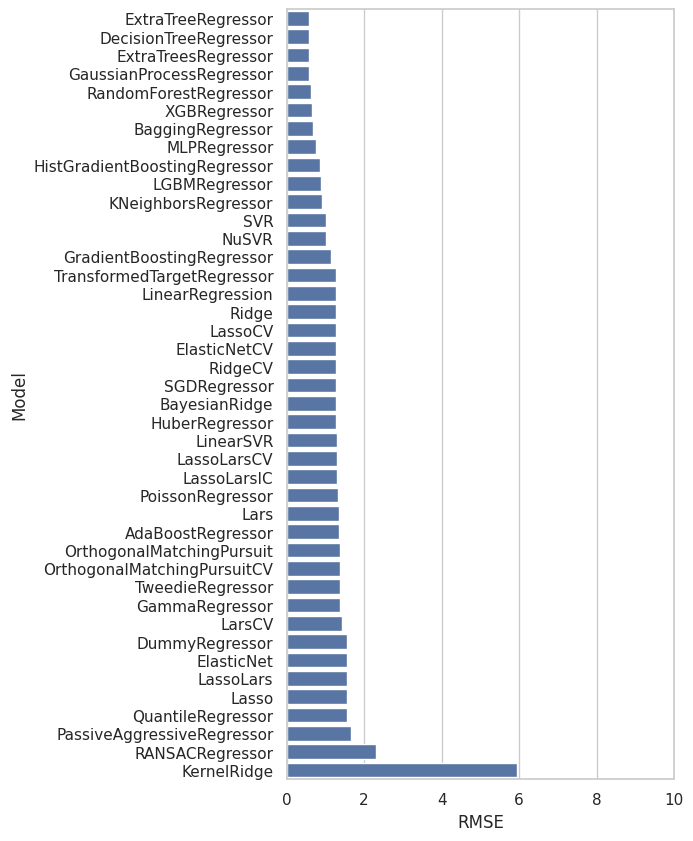

In [18]:
# Bar plot of RMSE values
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=models_train.index, x="RMSE", data=models_train)
ax.set(xlim=(0, 10))

[(0.0, 10.0)]

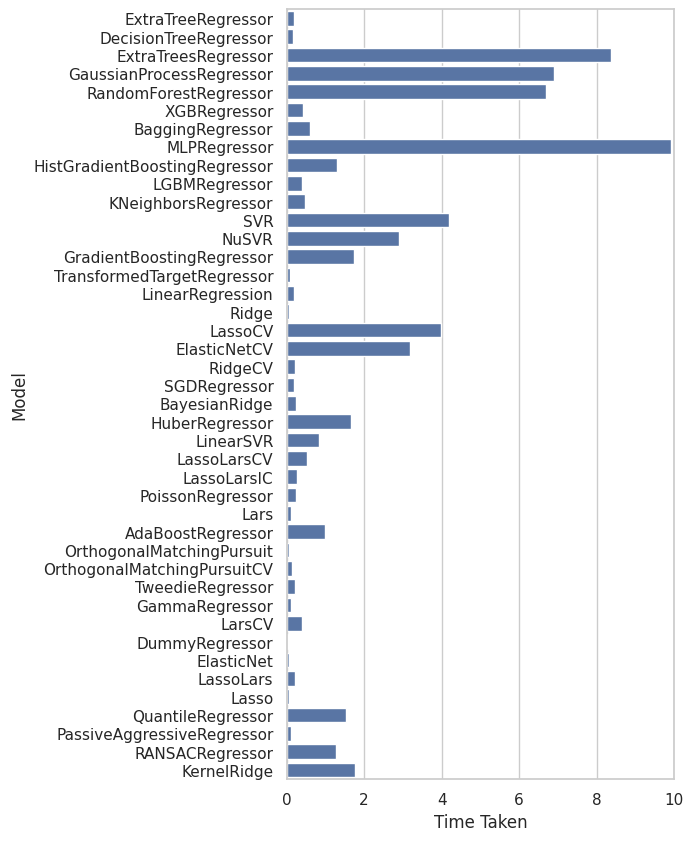

In [19]:
# Bar plot of calculation time
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=models_train.index, x="Time Taken", data=models_train)
ax.set(xlim=(0, 10))